### Imports and Constants

In [1]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import Results

In [ ]:
SUPPORT_SET_METRICS = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
PREDICTION_METRICS = ['accuracy', 'logistic']
LOGIT_METRICS = [Metrics.compute_logit_variance, Metrics.compute_logit_pairwise_distance]

def collate_datasets_results():
    all_datasets_results = {}
    for dn in DATASET_NAMES:
        runs = list()
        runs_paths = os.listdir(f"../results/{dn}/method_results")
        runs_paths.sort()
        for fn in runs_paths:
            result = Results.load_result(f"../results/{dn}/method_results/{fn}")
            runs.append(result.to_dataframe_row())
        all_datasets_results[dn] = pd.concat(runs, axis=0, ignore_index=True)
    return all_datasets_results

def populate_datasets_results(all_datasets_results, n_samples):
    feature_metrics = []
    # do hamming, model count, 
    for dn, df in all_datasets_results.items():
        new_cols = defaultdict(list)
        for i, row in df.iterrows():
            # load rashomon set for this run
            w_rset = row['w_rset'][:100,:]
            w_opt = row['w_opt']
            l0 = row['l0']
            l2 = 0.001 # l2 = row['l2']
            method_type = row['method_type']

            # load dataset used for this run
            dataset = Results.load_dataset(f"../results/{dn}", {'l0': l0, 'l2': l2})
            bin_X = dataset['bin_X']
            y = dataset['y']
            cum_header = dataset['cum_header']

            # compute diversity metrics on the support set
            for metric in SUPPORT_SET_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)
            
            # compute diversity metrics on the predicted values
            for metric in PREDICTION_METRICS:
                losses, opt_loss = ModelUtils.get_loss(bin_X, y, w_rset, loss_type=metric, w_opt=w_opt, l2=l2)
                new_cols[metric].append(losses)
                new_cols[metric + '_opt'].append(opt_loss)

            # compute logit metrics
            logits = bin_X @ w_rset.T
            for metric in LOGIT_METRICS:
                new_cols[metric.__name__].append(metric(logits))

            # compute feature-specific metrics
            pass
        # add new_cols to df
        for key, value in new_cols.items():
            df[key] = value

In [3]:
    # for dname, df in all_datasets_results.items():
    #     print(dname)
    #     accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
    #     model_count, headers = [], []
    #     feature_to_shape_diversities = []
    #     feature_to_shape_differences = []
    #     logit_variances = []
    #     logit_distances = []

    #     path = f"../datasets/{dname}.csv"
    #     X, y, header, new_header, sample_p = DatasetUtils.get_binned_dataset(path, df.iloc[0]['n_estimators'])
    #     for i, row in df.iterrows():
    #         w_rset = row["w_rset"]
    #         w_opt = row["w_opt"]
    #         predictions = row["predictions"]
    #         l2 = 0.001
            
    #         model_count.append((w_rset.shape[0], (w_rset.shape[0], w_rset.shape[0])))
    #         if w_rset.shape[0] == 0:
    #             accuracy.append((0, (0, 0)))
    #             logistic.append((0, (0, 0)))
    #             hamming.append((0, (0, 0)))
    #             iou.append((0, (0, 0)))
    #             euclidean.append((0, (0, 0)))
    #             cosine.append((0, (0, 0)))
    #             logit_variances.append((0, (0, 0)))
    #             logit_distances.append((0, (0, 0)))
    #             feature_to_vi.append([])
    #             feature_to_shape_diversities.append({feature: [] for feature in new_header[1:]})
    #             feature_to_shape_differences.append({feature: [] for feature in new_header[1:]})
    #             headers.append(new_header)
    #             continue

    #         print(f"\t{i}: {w_rset.shape[0]}")
    #         if w_rset.shape[0] > n_samples: 
    #             w_rset = w_rset[:n_samples]
    #             predictions = predictions[:n_samples]
    #             print(f"\ttruncated to {n_samples}")

    #         accuracy.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="accuracy")[0]))
    #         logistic.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p)[0]))
    #         hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=n_samples))

    #         logits = X @ w_rset.T
    #         logit_variances.append(compute_logit_variance(logits))
    #         logit_distances.append(average_pairwise_diversity(logits, euclidean_distance, limit=n_samples))

    #         iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=n_samples))
    #         euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=n_samples))
    #         cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=n_samples))
    #         headers.append(new_header)

    #         feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
    #         # get feature to indices
    #         feature_to_indices = defaultdict(list)
    #         feature_to_widths = defaultdict(list)
    #         feature_ranges = get_feature_ranges(np.array(new_header[1:]))
    #         for feature, ranges in feature_ranges.items():
    #             for r in ranges:
    #                 if len(r) == 1:
    #                     feature_to_widths[feature].append(r[0])
    #                 else:
    #                     feature_to_widths[feature].append(r[1] - r[0])
    #         for i, col in enumerate(new_header[1:]):
    #             match = re.search(r'([a-zA-Z]+)', col)
    #             if match:
    #                 feature = match.group(1)
    #                 feature_to_indices[feature].append(i)
            
    #         feature_to_shape_diversity = defaultdict(list)
    #         feature_to_shape_difference = defaultdict(list)
    #         for feature, indices in feature_to_indices.items():
    #             indices = np.array(indices)
    #             average_X_row = X[:, indices]
    #             feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=n_samples, X=average_X_row))
    #             feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=n_samples, X=feature_to_widths[feature]))
    #         feature_to_shape_diversities.append(feature_to_shape_diversity)
    #         feature_to_shape_differences.append(feature_to_shape_difference)
        
    #     df['accuracy'] = accuracy
    #     df['logistic'] = logistic
    #     df['hamming'] = hamming
    #     df['iou'] = iou
    #     df['euclidean'] = euclidean
    #     df['cosine'] = cosine
    #     df['model_count'] = model_count
    #     df['header'] = headers
    #     df['feature_to_vi'] = feature_to_vi
    #     df['feature_to_shape_diversities'] = feature_to_shape_diversities
    #     df['feature_to_shape_differences'] = feature_to_shape_differences
    #     df['logit_variances'] = logit_variances
    #     df['logit_distances'] = logit_distances

### Compute All Metrics

In [3]:
n_samples = 100
all_datasets_results = collate_datasets_results()

In [4]:
populate_datasets_results(all_datasets_results, n_samples)

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.p

In [5]:
with open(f'all_datasets_results.pkl', 'wb') as f:
    pickle.dump(all_datasets_results, f)

### Get Plotting Functions

In [44]:
result = Results.load_result(f"../results/bank/method_results/swapping_l0_0.001_l2_0.001_m_1.05_samples_60_k_1.pkl")
w_opt = result.w_opt
w_rset = result.w_rset

dataset = Results.load_dataset(f"../results/bank", {'l0': 0.001, 'l2': 0.001})
bin_X = dataset['bin_X']
cum_X = dataset['cum_X']
y = dataset['y']
cum_header = dataset['cum_header']
def convert_cumulative_to_binned(w_rset, header):
    w_rset_binned = []
    header_object = ModelUtils.get_header_object(header)
    for w in w_rset:
        new_w = np.zeros(len(header))
        i = w.shape[0] - 1
        for feat, thresholds in reversed(header_object.items()):
            if feat == 'intercept':
                new_w[i] = w[i]
                continue
            cumulative_weight = 0.0
            for _ in range(len(thresholds)):
                cumulative_weight += w[i]
                new_w[i] = cumulative_weight
                i -= 1
        w_rset_binned.append(np.array(new_w))
    return np.vstack(w_rset_binned)

w_rset_binned = convert_cumulative_to_binned(w_rset, cum_header)
w_opt_binned = convert_cumulative_to_binned(np.array([w_opt]), cum_header)[0]

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl


In [44]:
with open(f'all_datasets_results.pkl', 'rb') as f:
    all_datasets_results = pickle.load(f)
    
def get_label(row):
    if row['method_type'] == MethodType.SWAPPING:
        return f"{row['method_type'].value} {row['k']}"
    elif row['method_type'] == MethodType.ELLIPSOID:
        label = f"{row['method_type'].value} {row['sampling']}"
        if row['distance_metric']:
            label += f" ({row['distance_metric']})"
        return label
    elif row['method_type'] == MethodType.MCMC:
        return f"{row['method_type'].value} {row['proposal_function']}, sample {row['sample_from_rset']}"
    else:
        return row['method_type'].value

want_to_plot = [
    'ellipsoid surface (euclidean)',
    # 'mcmc random, sample 20.0',
    'mcmc correlation_swap, sample 20.0',
    'mcmc random_swap, sample 20.0',
    # 'mcmc random, sample 0.0',
    'mcmc correlation_swap, sample 0.0',
    'mcmc random_swap, sample 0.0',
    'swapping 3.0',
]
for dn, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if want_to_plot and get_label(row) not in want_to_plot:
            df.drop(i, inplace=True)

In [20]:
feature_to_shape_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

def show_loss_distributions(all_datasets_results, dn, loss_type):
    df = all_datasets_results[dn]
    plotter = MultiPlotter(title=f"{dn} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        losses = row[loss_type]
        opt_loss = row[loss_type + '_opt']
        plotter.add_distribution(losses, get_label(row), opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname, df in all_datasets_results.items():
        labels = [get_label(row) for _, row in df.iterrows()]
        list_of_mean_and_cis = df[metric].to_list()
        if metric in PREDICTION_METRICS:
            list_of_mean_and_cis = [Metrics.get_mean_and_ci(distribution) for distribution in list_of_mean_and_cis]
        plotter.add_bar(list_of_mean_and_cis, dname, labels)
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=100):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        dataset = Results.load_dataset(f"../results/{dname}", {'l0': 0.001, 'l2': 0.001})
        plotter.add_shape_function(np.array(dataset['bin_header'][1:]), row['w_rset'][:n_samples, 1:], get_label(row))
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        plotter.add_variable_importance_distribution(row['feature_to_vi'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_vi'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

def get_table_results(all_dataset_results):
    details = ['dataset', 'method', 'runtime']
    distribution_metrics = ['accuracy', 'logistic']
    metrics = ['inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity'] #'compute_logit_variance', 'compute_logit_pairwise_distance', 'hamming']
    # feature_based_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

    combined_df = pd.DataFrame()
    for dname, df in all_dataset_results.items():
        df['method'] = [get_label(row) for _, row in df.iterrows()]
        df = df[details + distribution_metrics + metrics].copy()
        df['runtime'] = df['runtime'].apply(lambda v: round(v, 3))
        df[distribution_metrics] = df[distribution_metrics].applymap(lambda v: round(np.average(v), 3))
        df[metrics] = df[metrics].applymap(lambda v: round(v[0], 3))
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

### Visualizations

25


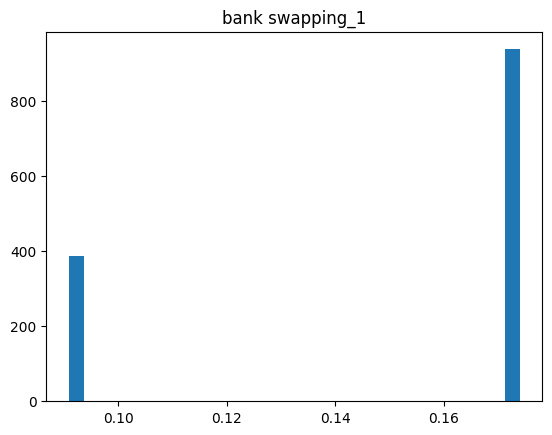

25


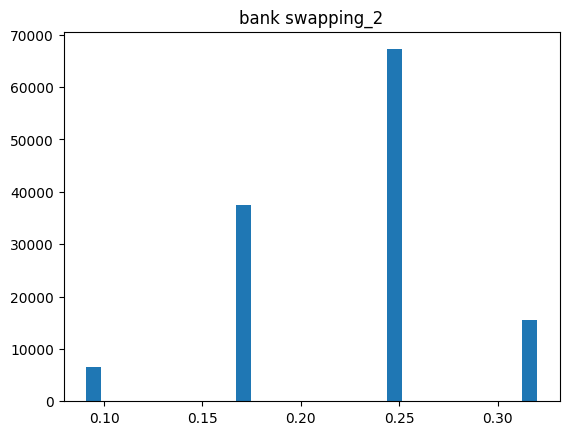

25


KeyboardInterrupt: 

In [ ]:
for dataset, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if not row['method'].startswith('swapping'):
            continue
        # distribution = []
        # w_rset = row['w_rset']
        # for w in w_rset:
        #     distribution.extend(list(w.nonzero()[0]))

        # plt.title(f"{dataset} {row['method']}")
        # plt.hist(distribution, bins=30)
        # plt.show()

        iou_distribution = []
        w_rset = row['w_rset']
        print(w_rset.shape[1])
        for i in range(w_rset.shape[0]):
            for j in range(i + 1, w_rset.shape[0]):
                iou_distribution.append(inverse_IoU(w_rset[i], w_rset[j]))
        plt.title(f"{dataset} {row['method']}")
        plt.hist(iou_distribution, bins=30)
        plt.show()

In [21]:
all_datasets_results['bank']

,method_type,dataset,n_estimators,n_support_set,n_samples,w_rset,w_opt,rset_bound,runtime,l0,...,k,inverse_IoU,euclidean_distance,inverse_cosine_similarity,accuracy,accuracy_opt,logistic,logistic_opt,compute_logit_variance,compute_logit_pairwise_distance
5,MethodType.ELLIPSOID,bank,50,20,1000,"[[-0.15477724638428678, 0.0, 0.0, 0.0, 0.0, 0....","[-0.33323823025138594, 0.0, 0.0, 0.0, 0.0, 0.0...",0.256566,8.306473,0.001,...,NaN,"(0.0, [0.0, 0.0])","(35.89735019317509, [35.89735019317509, 35.897...","(0.17537182588861802, [0.17537182588861802, 0....","[0.09798717097987171, 0.09798717097987171, 0.0...",0.096660,"[0.25546028035919605, 0.2560819272915495, 0.25...",0.244331,"(2.7482402569665783, [1.9483329883460252, 3.76...","(18.81458254231609, [0.0, 53.92576969961518])"
12,MethodType.MCMC,bank,50,20,1072,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,447.821365,0.001,...,NaN,"(0.2278202802206793, [0.2278202802206793, 0.22...","(53.1078824531931, [53.1078824531931, 53.10788...","(0.2879312328535338, [0.2879312328535338, 0.28...","[0.09643884096438841, 0.1041804910418049, 0.09...",0.096439,"[0.2443484497913396, 0.26141711036869314, 0.26...",0.244348,"(3.3502663444229612, [2.1234824223539337, 4.87...","(21.586083405210957, [2.7765276574370827, 56.2..."
13,MethodType.MCMC,bank,50,20,1072,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,414.167470,0.001,...,NaN,"(0.055417688058695826, [0.055417688058695826, ...","(71.69861606619499, [71.69861606619499, 71.698...","(0.5938490387233014, [0.5938490387233014, 0.59...","[0.09643884096438841, 0.1154611811546118, 0.12...",0.096439,"[0.2443484497913396, 0.3272210507792444, 0.325...",0.244348,"(1.4943199008926487, [0.5595298499770834, 3.90...","(15.61573150035277, [3.558651262195559, 32.031..."
14,MethodType.MCMC,bank,50,20,1072,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,480.160212,0.001,...,NaN,"(0.01656570998976203, [0.01656570998976203, 0....","(69.22003569122225, [69.22003569122225, 69.220...","(0.41367270201118594, [0.41367270201118594, 0....","[0.09643884096438841, 0.10263216102632161, 0.1...",0.096439,"[0.2443484497913396, 0.2708858838558225, 0.268...",0.244348,"(3.068983066233966, [1.63546623341017, 5.32552...","(20.863923391964235, [3.1414205928892356, 53.5..."
15,MethodType.MCMC,bank,50,20,52,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,481.727179,0.001,...,NaN,"(0.34173369263542747, [0.34173369263542747, 0....","(33.895461533878155, [33.895461533878155, 33.8...","(0.16272001891444612, [0.16272001891444612, 0....","[0.09643884096438841, 0.09466932094669321, 0.0...",0.096439,"[0.2443484497913396, 0.25283981873103667, 0.25...",0.244348,"(3.2645336453183065, [2.3391920935586166, 4.19...","(15.188038671118749, [1.7896800146634206, 40.4..."
16,MethodType.MCMC,bank,50,20,52,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,400.900641,0.001,...,NaN,"(0.11586786985092803, [0.11586786985092803, 0....","(38.13882238605775, [38.13882238605775, 38.138...","(0.3305679927250718, [0.3305679927250718, 0.33...","[0.09643884096438841, 0.11656713116567131, 0.1...",0.096439,"[0.2443484497913396, 0.2896520570462219, 0.307...",0.244348,"(1.3668736670123212, [0.28130528364782603, 2.8...","(10.699876889185495, [3.0562202457528693, 22.9..."
17,MethodType.MCMC,bank,50,20,52,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,492.551820,0.001,...,NaN,"(0.08325058186554309, [0.08325058186554309, 0....","(34.450651800683126, [34.450651800683126, 34.4...","(0.16361521976595272, [0.16361521976595272, 0....","[0.09643884096438841, 0.0999778809997788, 0.10...",0.096439,"[0.2443484497913396, 0.2570814312531732, 0.251...",0.244348,"(3.

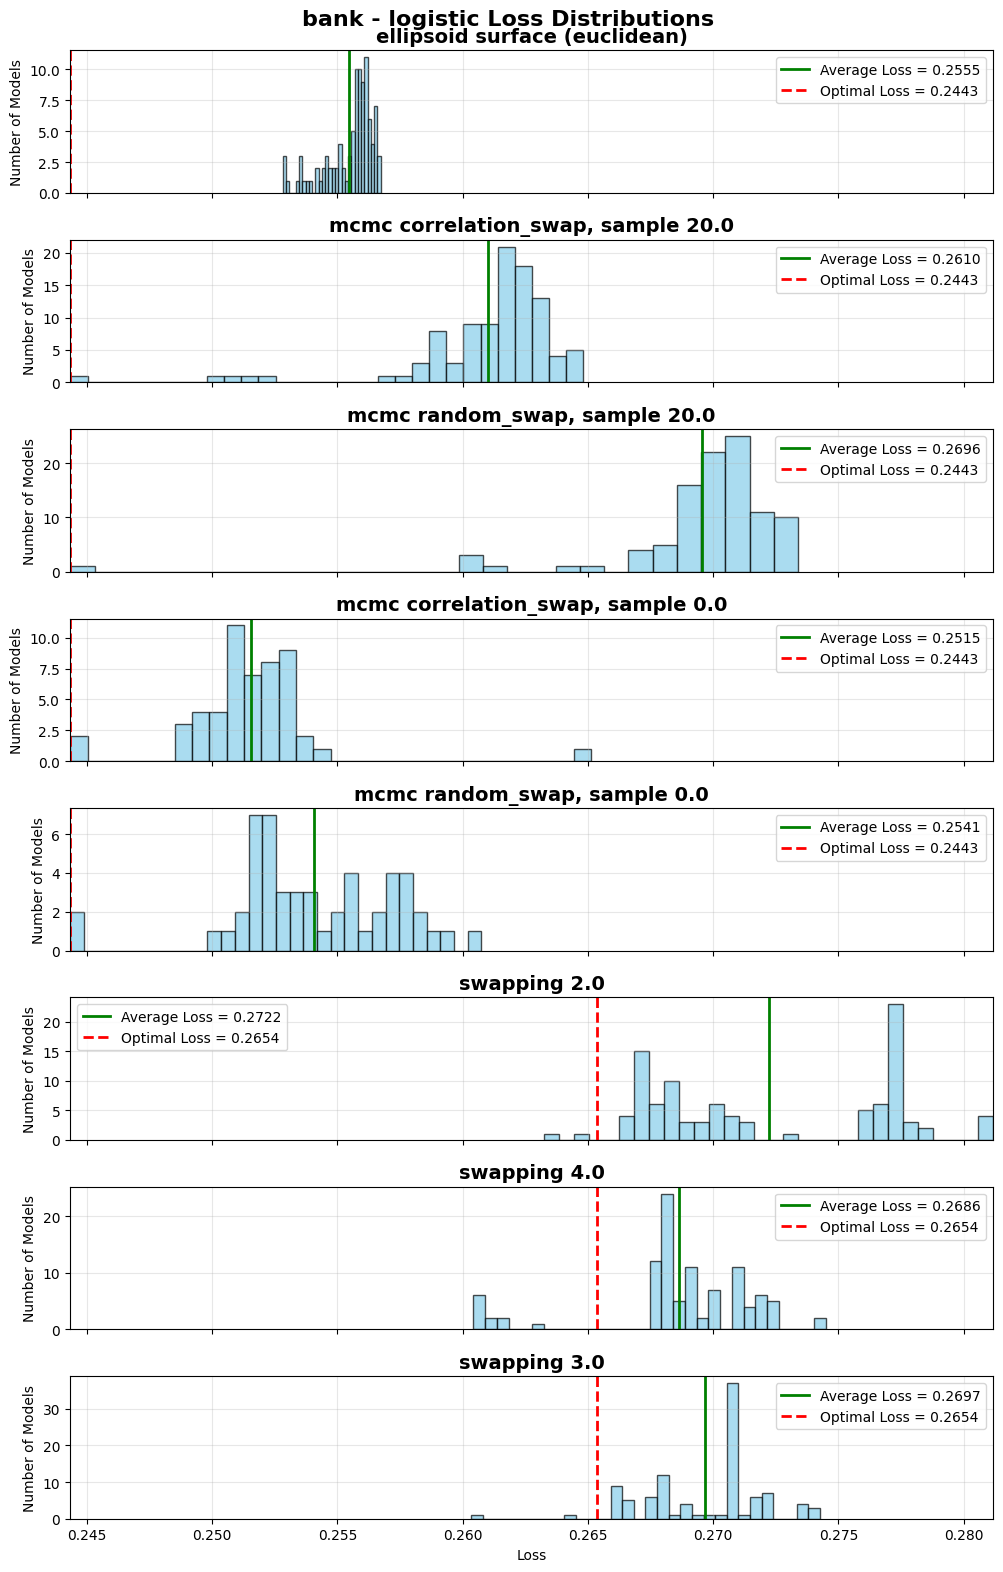

In [41]:
show_loss_distributions(all_datasets_results, "bank", "logistic")

In [50]:
all_datasets_results['bank'].columns

Index(['method_type', 'dataset', 'n_estimators', 'n_support_set', 'n_samples',
       'w_rset', 'w_opt', 'rset_bound', 'runtime', 'l0', 'l2', 'm', 'sampling',
       'distance_metric', 'proposal_function', 'sigma2', 'sample_from_rset',
       'beta', 'inverse_IoU', 'euclidean_distance',
       'inverse_cosine_similarity', 'accuracy', 'accuracy_opt', 'logistic',
       'logistic_opt', 'compute_logit_variance',
       'compute_logit_pairwise_distance'],
      dtype='object')

In [42]:
bar_metrics = ['accuracy', 'logistic', 'hamming', 'inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity', 'logit_variances', 'logit_distances']
bar_plot = get_bar_plot(all_datasets_results, 'logistic')

ValueError: x_labels must be the same for all bar charts

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl


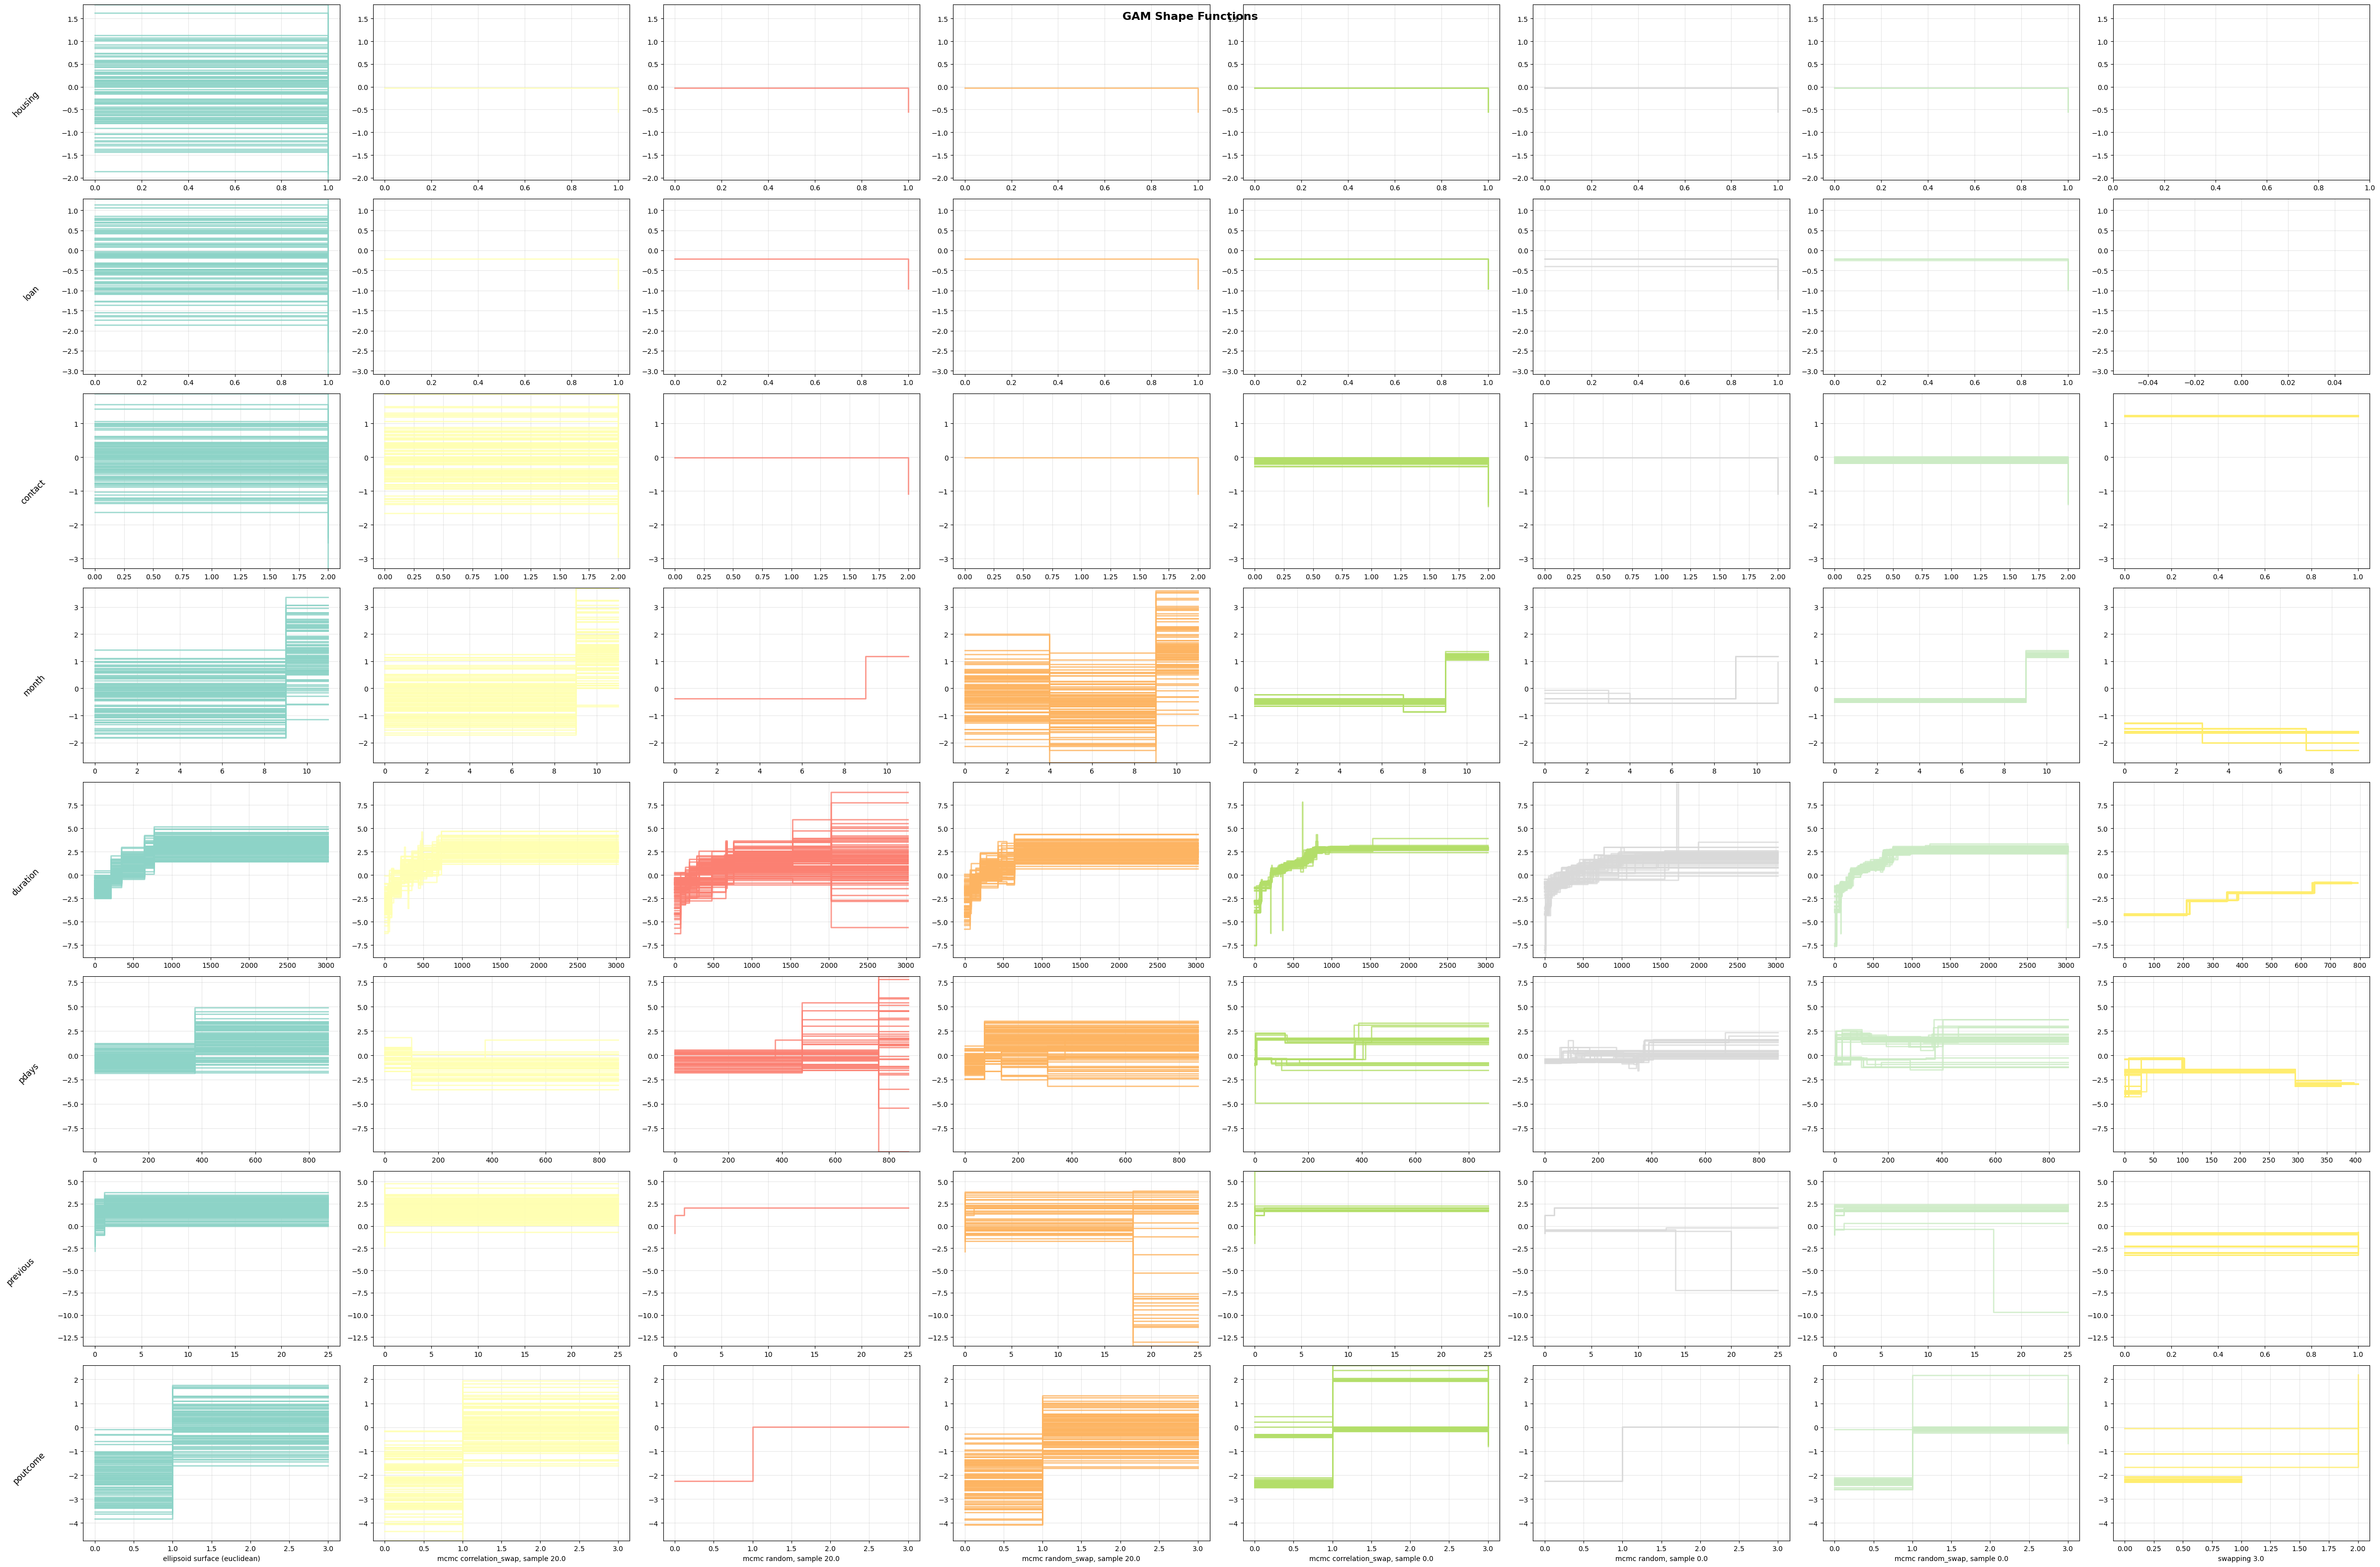

In [29]:
# ["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'bank')

In [31]:
variable_importance = get_variable_importance(all_datasets_results, 'bank')

KeyError: 'feature_to_vi'

In [32]:
model_reliance = get_model_reliance(all_datasets_results, "compas")

KeyError: 'feature_to_vi'

In [33]:
fsd = get_feature_to_shape_diversity(all_datasets_results, "diabetes", feature_to_shape_metrics[0])

KeyError: 'feature_to_shape_differences'

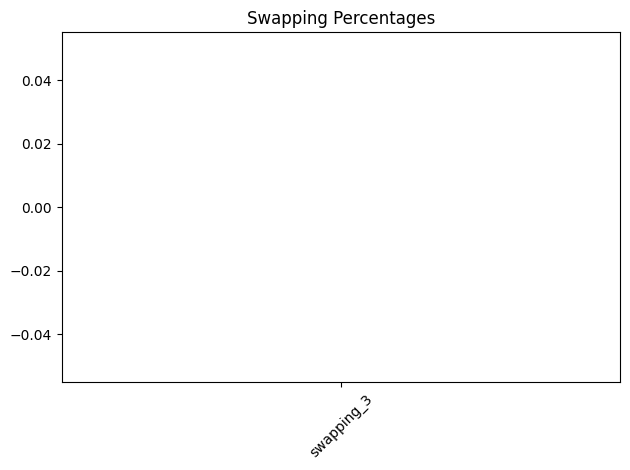

In [ ]:
# show_swapping_percentages(all_datasets_results, "bank")

In [45]:
get_table_results(all_datasets_results)

,dataset,method,runtime,accuracy,logistic,inverse_IoU,euclidean_distance,inverse_cosine_similarity
0,bank,ellipsoid surface (euclidean),8.306,0.098,0.255,0.000,35.897,0.175
1,bank,"mcmc correlation_swap, sample 20.0",447.821,0.103,0.261,0.228,53.108,0.288
2,bank,"mcmc random_swap, sample 20.0",480.160,0.105,0.270,0.017,69.220,0.414
3,bank,"mcmc correlation_swap, sample 0.0",481.727,0.098,0.252,0.342,33.895,0.163
4,bank,"mcmc random_swap, sample 0.0",492.552,0.099,0.254,0.083,34.451,0.164
5,bank,swapping 3.0,267.144,0.096,0.270,0.004,7.801,0.005
6,compas,ellipsoid surface (euclidean),14.251,0.329,0.617,0.000,14.628,0.415
7,compas,"mcmc correlation_swap, sample 20.0",669.838,0.329,0.617,0.088,24.792,0.644
8,compas,"mcmc random_swap, sample 20.0",687.647,0.327,0.617,0.072,26.052,0.584
9,compas,"mcmc correlation_swap, sample 0.0",669.641,0.320,0.604,0.072,6.090,0.124


In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names[1:]:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)